<a href="https://colab.research.google.com/github/BisratGetnet/Student-Score-Prediction/blob/main/Linear%20regression%20model%20%5Ball%20features%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/StudentPerformanceFactors.csv')
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

None

In [3]:
display(df.describe())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [5]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
            'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer.fit_transform(df[cat_cols])


In [7]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [8]:
yes_no_cols = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [9]:
remaining_cat_cols = list(set(cat_cols) - set(yes_no_cols))
df_encoded = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)

In [10]:
print(df_encoded.info())
print(df_encoded.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6607 non-null   int64
 1   Attendance                             6607 non-null   int64
 2   Extracurricular_Activities             6607 non-null   int64
 3   Sleep_Hours                            6607 non-null   int64
 4   Previous_Scores                        6607 non-null   int64
 5   Internet_Access                        6607 non-null   int64
 6   Tutoring_Sessions                      6607 non-null   int64
 7   Physical_Activity                      6607 non-null   int64
 8   Learning_Disabilities                  6607 non-null   int64
 9   Exam_Score                             6607 non-null   int64
 10  Peer_Influence_Neutral                 6607 non-null   bool 
 11  Peer_Influence_Positive       

In [11]:
df_encoded.head()

,Hours_Studied,Attendance,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Internet_Access,Tutoring_Sessions,Physical_Activity,Learning_Disabilities,Exam_Score,...,Distance_from_Home_Moderate,Distance_from_Home_Near,Motivation_Level_Low,Motivation_Level_Medium,School_Type_Public,Gender_Male,Teacher_Quality_Low,Teacher_Quality_Medium,Access_to_Resources_Low,Access_to_Resources_Medium
0,23,84,0,7,73,1,0,3,0,67,...,False,True,True,False,True,True,False,True,False,False
1,19,64,0,8,59,1,2,4,0,61,...,True,False,True,False,True,False,False,True,False,True
2,24,98,1,7,91,1,2,4,0,74,...,False,True,False,True,True,True,False,True,False,True
3,29,89,1,8,98,1,1,4,0,71,...,True,False,False,True,True,True,False,True,False,True
4,19,92,1,6,65,1,3,4,0,70,...,False,True,False,True,True,False,False,False,False,True


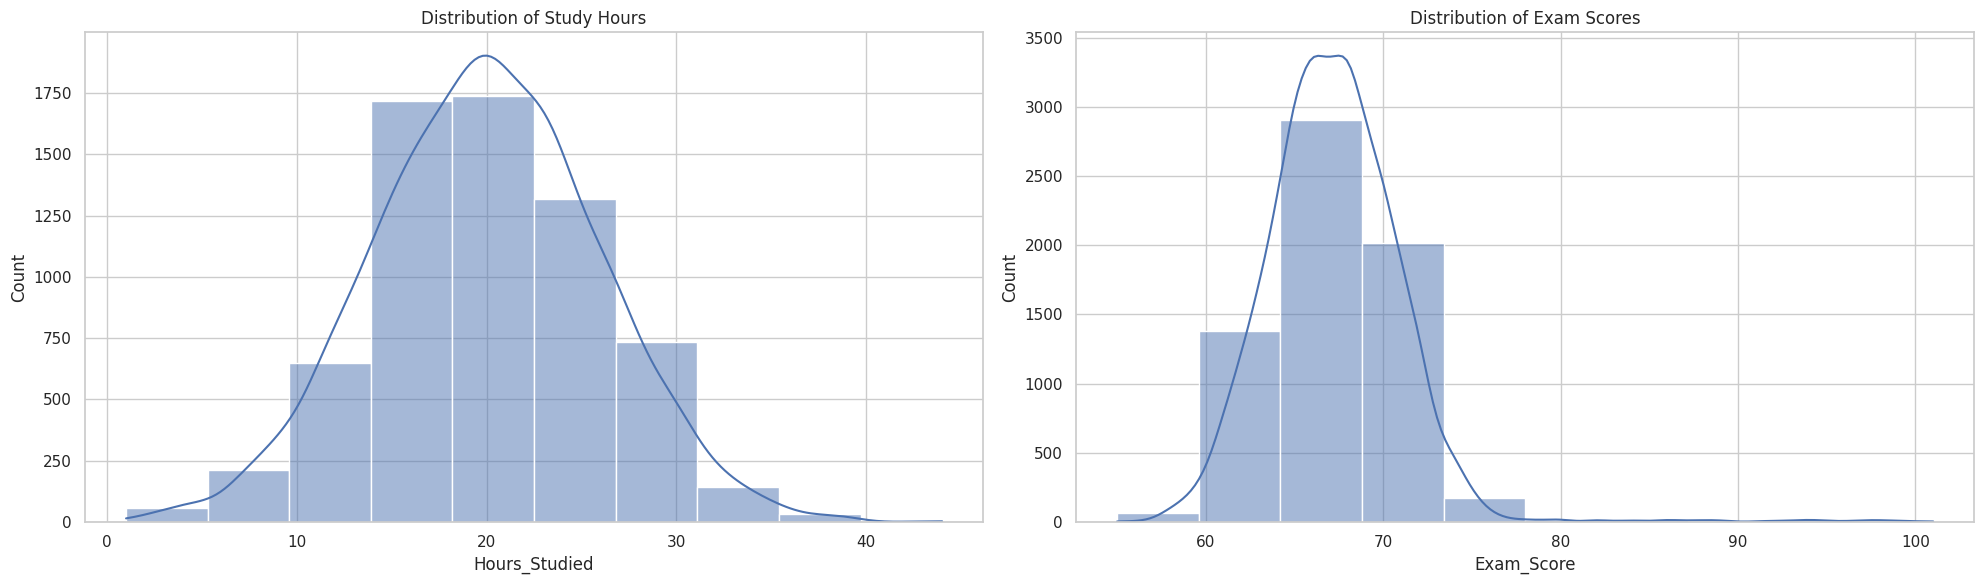

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20,6))  # one row, two columns for histograms

# Distribution of Hours_Studied
sns.histplot(df_encoded['Hours_Studied'], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Study Hours")

# Distribution of Exam_Score
sns.histplot(df_encoded['Exam_Score'], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Exam Scores")

plt.tight_layout()
plt.show()


/tmp/ipython-input-4149145435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


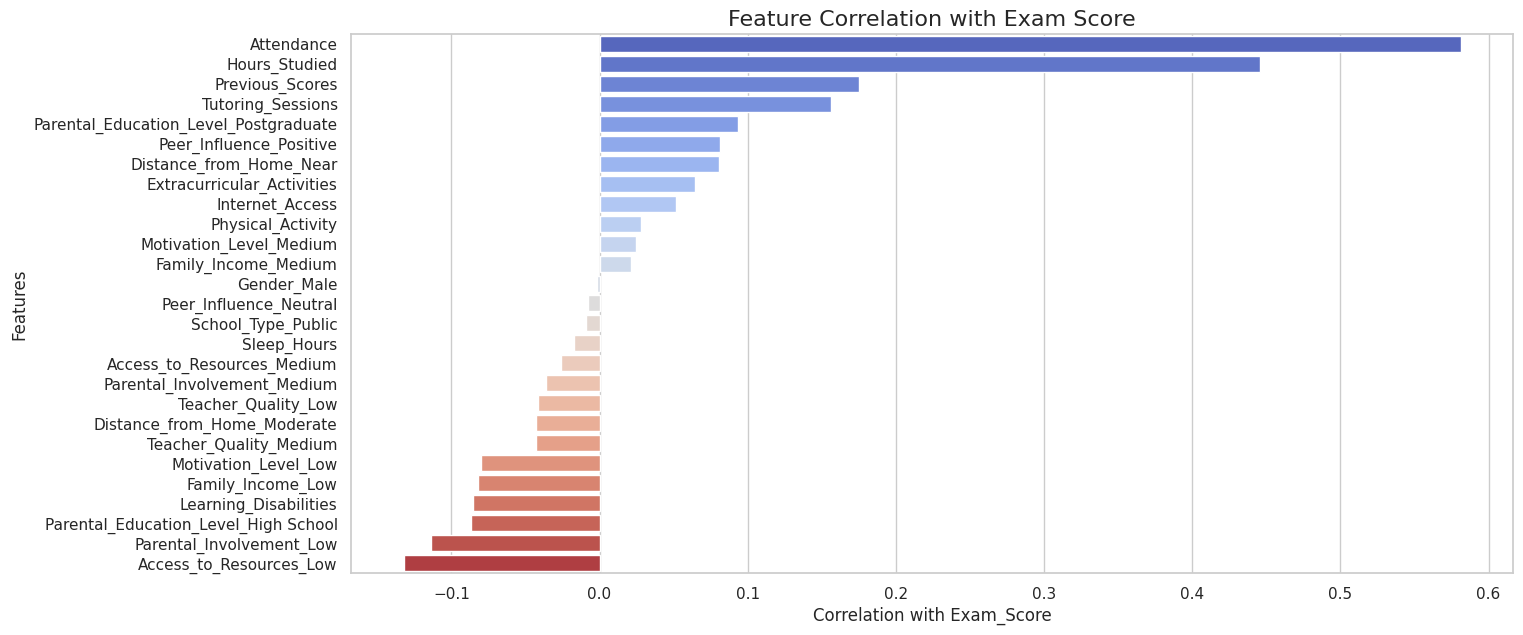

In [13]:
import numpy as np

# Compute correlation of each feature with Exam_Score
corr_with_target = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)

# Exclude Exam_Score itself
corr_with_target = corr_with_target.drop('Exam_Score')

plt.figure(figsize=(15, 7))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title("Feature Correlation with Exam Score", fontsize=16)
plt.xlabel("Correlation with Exam_Score")
plt.ylabel("Features")
plt.show()


In [14]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_encoded.drop('Exam_Score', axis=1)  # all features except target
y = df_encoded['Exam_Score']               # target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5285, 27)
X_test shape: (1322, 27)
y_train shape: (5285,)
y_test shape: (1322,)


Mean Squared Error (MSE): 3.26
R-squared (R²): 0.77


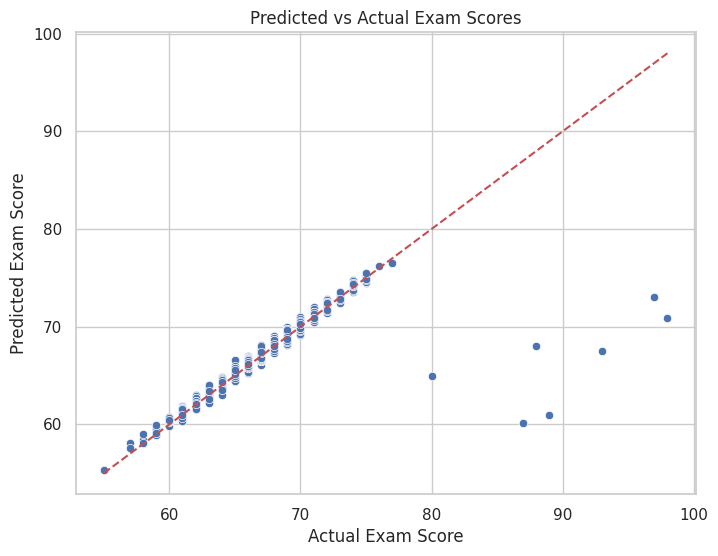

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual Exam Scores")
plt.show()


Polynomial Regression (degree=2) MSE: 3.57
Polynomial Regression (degree=2) R²: 0.75


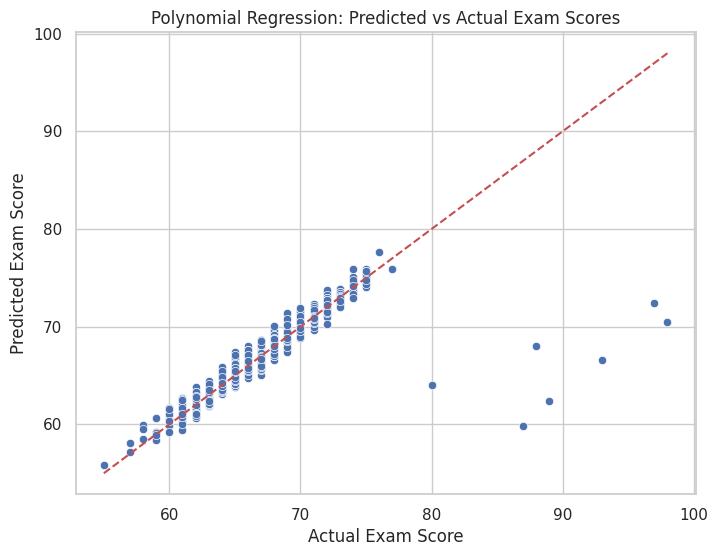

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Make predictions
y_pred = model_poly.predict(X_test_poly)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Regression (degree=2) MSE: {mse:.2f}")
print(f"Polynomial Regression (degree=2) R²: {r2:.2f}")


plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Polynomial Regression: Predicted vs Actual Exam Scores")
plt.show()
